In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

2026-05-13 15:02:04.565359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778684524.742507      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778684524.806619      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778684525.288054      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778684525.288093      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778684525.288095      57 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_DIR = "/kaggle/input/leaf-vs-non-leaf-images"

In [3]:
print(os.listdir(DATASET_DIR))

['non_leaf', 'leaf']


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 10400 images belonging to 2 classes.
Found 2600 images belonging to 2 classes.


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778684544.909969      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778684544.915874      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1778684549.284041     139 service.cc:152] XLA service 0x7e22e0003f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778684549.284091     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778684549.284096     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778684549.735498     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-13 15:02:32.356486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 15:02:32.504896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/325 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.5469 - loss: 2.4226

I0000 00:00:1778684555.087546     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 29/325 ━━━━━━━━━━━━━━━━━━━━ 1:38 334ms/step - accuracy: 0.6312 - loss: 1.5685

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


325/325 ━━━━━━━━━━━━━━━━━━━━ 166s 488ms/step - accuracy: 0.8289 - loss: 0.5183 - val_accuracy: 0.9604 - val_loss: 0.1046
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 101s 310ms/step - accuracy: 0.9523 - loss: 0.1296 - val_accuracy: 0.9469 - val_loss: 0.1582
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 101s 311ms/step - accuracy: 0.9664 - loss: 0.0977 - val_accuracy: 0.9662 - val_loss: 0.0933
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 97s 297ms/step - accuracy: 0.9764 - loss: 0.0731 - val_accuracy: 0.9623 - val_loss: 0.1117
Epoch 5/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 99s 303ms/step - accuracy: 0.9777 - loss: 0.0618 - val_accuracy: 0.9392 - val_loss: 0.2076
Epoch 6/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 98s 301ms/step - accuracy: 0.9843 - loss: 0.0467 - val_accuracy: 0.9346 - val_loss: 0.3539
Epoch 7/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 98s 300ms/step - accuracy: 0.9862 - loss: 0.0402 - val_accuracy: 0.9646 - val_loss: 0.1071
Epoch 8/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 98s 300ms/step - accuracy: 0.9827 - loss: 0.0477 - 

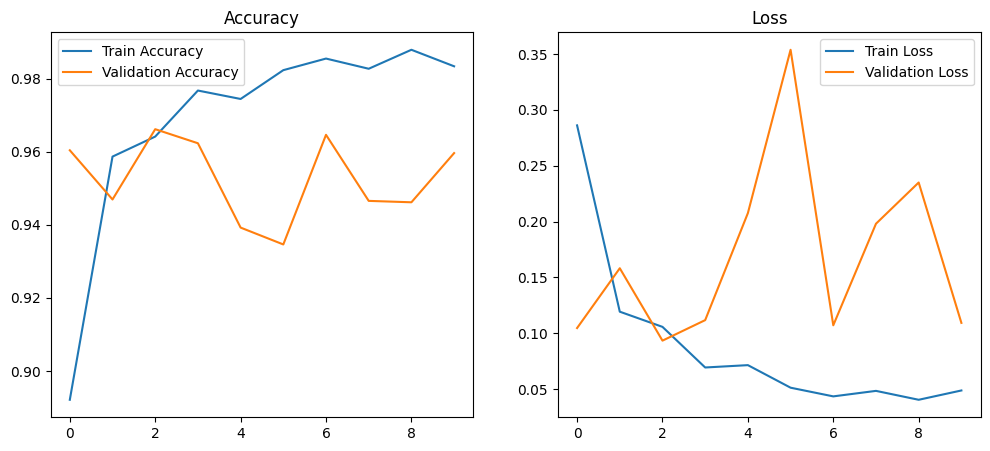

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [10]:
val_loss, val_accuracy = model.evaluate(val_generator)

print(f"\nFinal Validation Accuracy: {val_accuracy * 100:.2f}%")

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc * 100:.2f}%")
print(f"Final Validation Accuracy (Last Epoch): {val_acc * 100:.2f}%")

best_val_acc = max(history.history['val_accuracy'])
print(f"Best Validation Accuracy Achieved: {best_val_acc * 100:.2f}%")

82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 307ms/step - accuracy: 0.9510 - loss: 0.1350

Final Validation Accuracy: 95.96%
Final Training Accuracy: 98.34%
Final Validation Accuracy (Last Epoch): 95.96%
Best Validation Accuracy Achieved: 96.62%


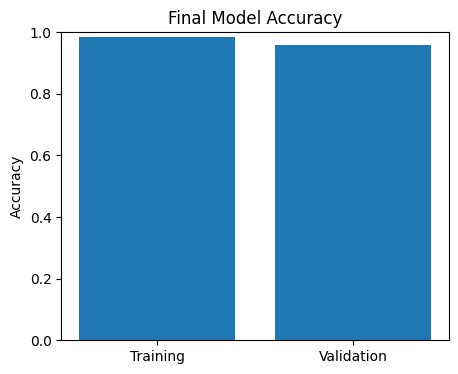

In [11]:
plt.figure(figsize=(5,4))
plt.bar(['Training', 'Validation'], [train_acc, val_acc])
plt.title('Final Model Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

In [12]:
print("\nClass Indices:")
print(train_generator.class_indices)


Class Indices:
{'leaf': 0, 'non_leaf': 1}


In [13]:
class_names = ['leaf', 'non_leaf']

In [14]:
import numpy as np

def predict(model, img):
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0][0]

    if prediction > 0.5:
        predicted_class = class_names[1]
        confidence = prediction * 100
    else:
        predicted_class = class_names[0]
        confidence = (1 - prediction) * 100

    return predicted_class, round(confidence, 2)

In [15]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 13000 files belonging to 2 classes.


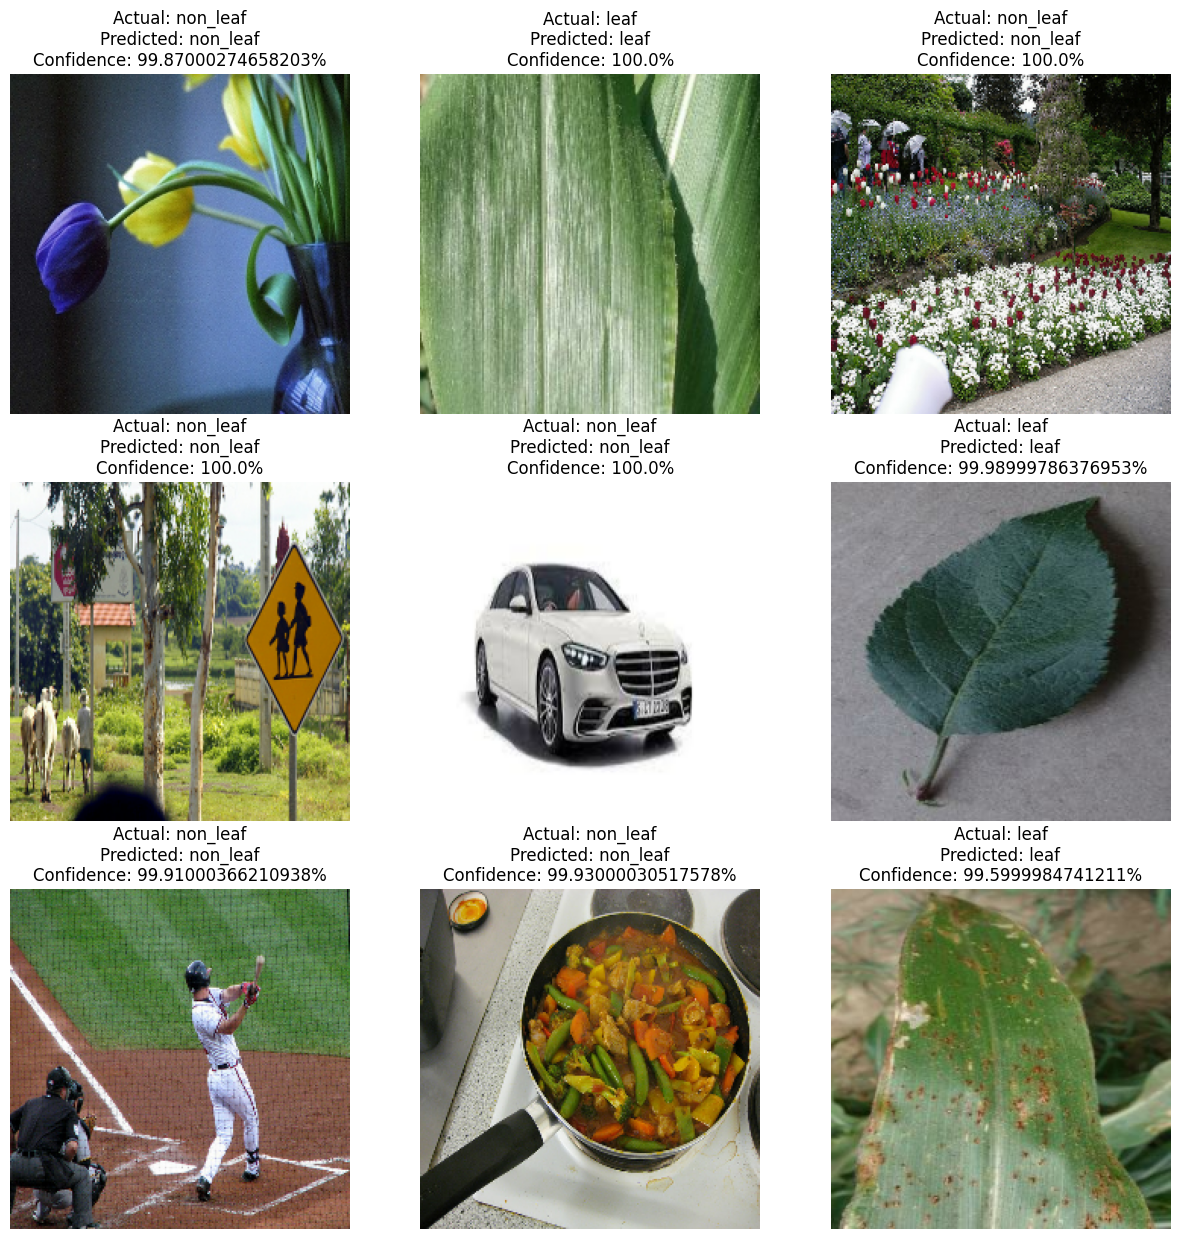

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence}%"
        )

        plt.axis("off")

plt.show()

In [17]:
model.save("leaf_vs_non_leaf_model.keras")